<a href="https://colab.research.google.com/github/UAMCAntwerpen/2040FBDBIC/blob/main/05_Molecular_similarity%2C_clustering_and_diversity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Install RDKit

In [ ]:
import sys
import os
import requests
import subprocess
import shutil
from logging import getLogger, StreamHandler, INFO

logger = getLogger(__name__)
logger.addHandler(StreamHandler())
logger.setLevel(INFO)

def install(
        chunk_size=4096,
        file_name="Miniconda3-latest-Linux-x86_64.sh",
        url_base="https://repo.continuum.io/miniconda/",
        conda_path=os.path.expanduser(os.path.join("~", "miniconda")),
        rdkit_version=None,
        add_python_path=True,
        force=False):

    python_path = os.path.join(
        conda_path,
        "lib",
        "python{0}.{1}".format(*sys.version_info),
        "site-packages",
    )

    if add_python_path and python_path not in sys.path:
        logger.info("add {} to PYTHONPATH".format(python_path))
        sys.path.append(python_path)

    if os.path.isdir(os.path.join(python_path, "rdkit")):
        logger.info("rdkit is already installed")
        if not force:
            return

        logger.info("force re-install")

    url = url_base + file_name
    python_version = "{0}.{1}.{2}".format(*sys.version_info)

    logger.info("python version: {}".format(python_version))

    if os.path.isdir(conda_path):
        logger.warning("remove current miniconda")
        shutil.rmtree(conda_path)
    elif os.path.isfile(conda_path):
        logger.warning("remove {}".format(conda_path))
        os.remove(conda_path)

    logger.info('fetching installer from {}'.format(url))
    res = requests.get(url, stream=True)
    res.raise_for_status()
    with open(file_name, 'wb') as f:
        for chunk in res.iter_content(chunk_size):
            f.write(chunk)
    logger.info('done')

    logger.info('installing miniconda to {}'.format(conda_path))
    subprocess.check_call(["bash", file_name, "-b", "-p", conda_path])
    logger.info('done')

    logger.info("installing rdkit")
    subprocess.check_call([
        os.path.join(conda_path, "bin", "conda"),
        "install",
        "--yes",
        "-c", "rdkit",
        "python=={}".format(python_version),
        "rdkit" if rdkit_version is None else "rdkit=={}".format(rdkit_version)])
    logger.info("done")

    import rdkit
    logger.info("rdkit-{} installation finished!".format(rdkit.__version__))


install()

add /root/miniconda/lib/python3.7/site-packages to PYTHONPATH
python version: 3.7.10
fetching installer from https://repo.continuum.io/miniconda/Miniconda3-latest-Linux-x86_64.sh
done
installing miniconda to /root/miniconda
done
installing rdkit
done
rdkit-2020.09.1 installation finished!


In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole

## Linear path-based FP's

10 bits ON out of the 10 bits in total
92 bits ON out of the 100 bits in total
223 bits ON out of the 1024 bits in total


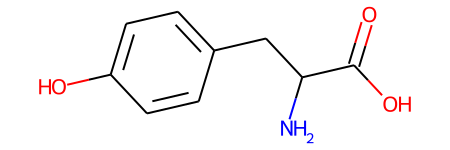

In [ ]:
mol = Chem.MolFromSmiles("Oc1ccc(CC(N)C(O)=O)cc1")

for fp_size in (10, 100, 1024):
  fp = Chem.RDKFingerprint(mol, fpSize=fp_size)
  print(len(list(fp.GetOnBits())), "bits ON out of the", len(fp), "bits in total")

mol

14 bits ON out of the 2048 bits in total
59 bits ON out of the 2048 bits in total
130 bits ON out of the 2048 bits in total
233 bits ON out of the 2048 bits in total


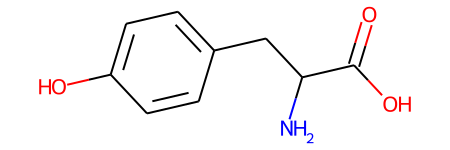

In [ ]:
mol = Chem.MolFromSmiles("Oc1ccc(CC(N)C(O)=O)cc1")

for max_path_length in (1,3,5,7):
  fp = Chem.RDKFingerprint(mol, maxPath=max_path_length)
  print(len(list(fp.GetOnBits())), "bits ON out of the", len(fp), "bits in total")

mol

## Circular FP's (ECFP)

Radius 1 : 11 bits ON out of the 1024 bits in total
Radius 2 : 16 bits ON out of the 1024 bits in total
Radius 3 : 17 bits ON out of the 1024 bits in total
Radius 4 : 17 bits ON out of the 1024 bits in total
Radius 5 : 17 bits ON out of the 1024 bits in total
Radius 6 : 17 bits ON out of the 1024 bits in total
Radius 7 : 17 bits ON out of the 1024 bits in total


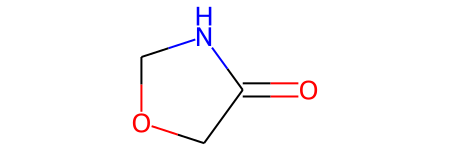

In [ ]:
from rdkit.Chem import AllChem
mol = Chem.MolFromSmiles("O1CC(=O)NC1")

for radius in range(1,8):
  fp = AllChem.GetMorganFingerprintAsBitVect(mol,radius,nBits=1024)
  print("Radius", radius, ":", len(list(fp.GetOnBits())), "bits ON out of the", len(fp), "bits in total")

mol

## MACCS keys

26 bits ON out of the 167 bits in total
[54, 84, 90, 95, 104, 111, 113, 123, 127, 131, 139, 143, 146, 151, 152, 154, 155, 156, 157, 158, 159, 161, 162, 163, 164, 165]


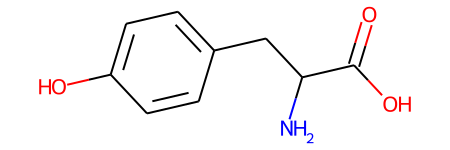

In [ ]:
from rdkit.Chem import MACCSkeys

mol = Chem.MolFromSmiles("Oc1ccc(CC(N)C(O)=O)cc1")
fp = MACCSkeys.GenMACCSKeys(mol)
print(len(list(fp.GetOnBits())), "bits ON out of the", len(fp), "bits in total")
print(list(fp.GetOnBits()))
mol

## Calculating similarity

In [ ]:
from rdkit import DataStructs

mol1 = Chem.MolFromSmiles("CCOC")
fp1 = Chem.RDKFingerprint(mol1, fpSize=50)
print(fp1.ToBitString())

mol2 = Chem.MolFromSmiles("CCO")
fp2 = Chem.RDKFingerprint(mol2, fpSize=50)
print(fp2.ToBitString())

tanimoto = DataStructs.FingerprintSimilarity(fp1, fp2)
print(tanimoto)

00000000101000001000001011010000000000000001000100
00000000001000001000000011010000000000000000000000
0.5555555555555556


In [ ]:
smiles = ["CO", "CCCO", "CCCOCCC"]
mols = []
for s in smiles: mols.append(Chem.MolFromSmiles(s))
fps = []
for mol in mols: fps.append(Chem.RDKFingerprint(mol))
ref = Chem.RDKFingerprint(Chem.MolFromSmiles("CCCO"))

for fp in fps:
  tversky = DataStructs.TverskySimilarity(ref, fp, 0.1, 0.9)
  print("%.2f" % tversky)

print()
for fp in fps:
  tversky = DataStructs.TverskySimilarity(ref, fp, 0.9, 0.1)
  print("%.2f" % tversky)


0.71
1.00
0.48

0.22
1.00
0.89


## Similarity in practice

In this exercise, a file with 10,000 compounds (SMILES format) is downloaded from the UAMC GitHub repo, and then a similarity search is performed to identify the compound that is most similar to aspirin ("CC(=O)OC1=CC=CC=C1C(=O)O")

In [ ]:
# Download the SMILES file from GitHub
import requests
url = "https://raw.githubusercontent.com/UAMCAntwerpen/2040FBDBIC/main/compounds_10k.smi"
smiles = requests.get(url).text.split("\n")

# Aspirin is the query molecule
query = Chem.RDKFingerprint(Chem.MolFromSmiles("CC(=O)OC1=CC=CC=C1C(=O)O"))

# Loop over all molecules and keep the one with the highest similarity
max_sim = 0.0
best_hit = ""
for s in smiles:
  mol = Chem.MolFromSmiles(s)
  fp = Chem.RDKFingerprint(mol)
  tanimoto = DataStructs.FingerprintSimilarity(fp, query)
  if tanimoto >= max_sim:
    max_sim = tanimoto
    best_hit = s

# Show the best mol
mol = Chem.MolFromSmiles(best_hit) 
print(max_sim)
mol

RDKit ERROR: [13:40:36] SMILES Parse Error: syntax error while parsing: 404:
RDKit ERROR: [13:40:36] SMILES Parse Error: Failed parsing SMILES '404:' for input: '404:'


ArgumentError: ignored

Note: you can also use other similarity metrics such as the Tversky coefficient. Try this out to see how the results will alter.

## Maximal common substructure (MCSS)

In [ ]:
from rdkit.Chem import rdFMCS

morphine = Chem.MolFromSmiles("CN1CC[C@]23C4=C5C=CC(O)=C4O[C@H]2[C@H](C=C[C@H]3[C@H]1C5)O")
codeine = Chem.MolFromSmiles("CN1CC[C@]23[C@@H]4[C@H]1CC5=C2C(O[C@H]3[C@@H](O)C=C4)=C(OC)C=C5")
heroine = Chem.MolFromSmiles("CN([C@H](CC(C=C1)=C23)[C@@H]4C=C[C@@H]5OC(C)=O)CC[C@]43[C@H]5OC2=C1OC(C)=O")

mols = [morphine, codeine, heroine]
mcss = rdFMCS.FindMCS(mols)
Chem.MolFromSmarts(mcss.smartsString)

In [ ]:
%%timeit
m1 = Chem.MolFromSmiles("C[C@H](C[C@@](C)(O1)[C@H](O[C@@H]2O[C@H](C)C[C@H](N(C)C)[C@H]2O)[C@@H](C)[C@H](O[C@H]3C[C@@](C)(OC)[C@@H](O)[C@H](C)O3)[C@H]4C)[C@@]1([H])[C@H](C)[C@H](C(C)=O)OC4=O")
m2 = Chem.MolFromSmiles("C[C@H]1[C@@H](O[C@@H]2O[C@@H](C)[C@H](O)[C@@](OC)(C)C2)[C@H](C)[C@H](O[C@@H]3O[C@H](C)C[C@H](N(C)C)[C@H]3O)[C@@](O)(C)C[C@H](C)[C@H](N)[C@H](C)CN(C)CCOC1=O")

mols = [m1, m2]
mcss = rdFMCS.FindMCS(mols)

In [ ]:
Chem.MolFromSmarts(mcss.smartsString)

## Clustering

In [ ]:
# Six molecules
smiles = ["c1ccccc1", "c1cccnc1", "c1ncncc1", "C1CC1", "CC=O", "NCC"]
mols = [Chem.MolFromSmiles(x) for x in smiles]
fps = [AllChem.GetMorganFingerprintAsBitVect(x, 2, nBits=20) for x in mols]
display(Draw.MolsToGridImage(mols, molsPerRow=3))

In [ ]:
import numpy as np

# Show the fingerprints
for i in range(len(fps)): print("%s %s" % (fps[i].ToBitString(), smiles[i]))

In [ ]:
# Convert to format which is useable by clustering algorithm
nps = [np.array(x) for x in fps]
X = np.array(nps)
print(X)

In [ ]:
# Hierarchical clustering
from sklearn.cluster import AgglomerativeClustering
clusterEngine = AgglomerativeClustering(n_clusters = 3)
clusterEngine.fit(X)

labels = [str(x) for x in clusterEngine.labels_]
display(Draw.MolsToGridImage(mols, molsPerRow=3, legends=labels))

In [ ]:
# Non-hierarchical clustering: k-means
from sklearn.cluster import KMeans
clusterEngine = KMeans(n_clusters = 3)
clusterEngine.fit(X)

labels = [str(x) for x in clusterEngine.labels_]
display(Draw.MolsToGridImage(mols, molsPerRow=3, legends=labels))

In [ ]:
centers = clusterEngine.cluster_centers_
print(centers)

## Model building

#### Performance metrics

In [ ]:
# Real data
real = np.array([1,1,1,1,0,0,1,0,1,0,1,0,1,1,0,0,1,0,1,1])

# Predictions from a good model
good = np.array([1,0,1,1,0,1,1,0,1,0,1,0,1,0,0,0,1,0,1,1])

# Predictions from a bad model
bad = np.array([0,0,0,0,1,1,0,1,0,1,0,1,0,0,1,1,0,1,0,0])

# Predictions from a random model
random = np.random.randint(2, size=20)

print("Real  ", real)
print("Good  ", good)
print("Bad   ", bad)
print("Random", random)

In [ ]:
# Function to calculate number of true positives
def TP(real, pred):
  n = 0
  for i in range(len(real)):
    if real[i] == 1 and pred[i] == 1: n += 1
  return float(n)

In [ ]:
# Function to calculate number of false positives
def FP(real, pred):
  n = 0
  for i in range(len(real)):
    if real[i] == 0 and pred[i] == 1: n += 1
  return float(n)

In [ ]:
# Function to calculate number of true negatives
def TN(real, pred):
  n = 0
  for i in range(len(real)):
    if real[i] == 0 and pred[i] == 0: n += 1
  return float(n)

In [ ]:
# Function to calculate number of false negatives
def FN(real, pred):
  n = 0
  for i in range(len(real)):
    if real[i] == 1 and pred[i] == 0: n += 1
  return float(n)

In [ ]:
# Apply metrics onto the three models

# 1. Good model
print("Good model")
print("TP", TP(real, good))
print("TN", TN(real, good))
print("FP", FP(real, good))
print("FN", FN(real, good))

# 2. Bad model
print("Bad model")
print("TP", TP(real, bad))
print("TN", TN(real, bad))
print("FP", FP(real, bad))
print("FN", FN(real, bad))

# 3. Random model
print("Random model")
print("TP", TP(real, random))
print("TN", TN(real, random))
print("FP", FP(real, random))
print("FN", FN(real, random))

In [ ]:
# Rates
def TPR(real, pred):
  tp = TP(real, pred)
  fn = FN(real, pred)
  return tp / (tp + fn)

def TNR(real, pred):
  tn = TN(real, pred)
  fp = FP(real, pred)
  return tn / (tn + fp)

def FPR(real, pred):
  fp = FP(real, pred)
  tn = TN(real, pred)
  return fp / (fp + tn)

def FNR(real, pred):
  fn = FN(real, pred)
  tp = TP(real, pred)
  return fn / (fn + tp)

In [ ]:
# Apply metrics onto the three models

# 1. Good model
print("Good model")
print("TPR", TPR(real, good))
print("TNR", TNR(real, good))
print("FPR", FPR(real, good))
print("FNR", FNR(real, good))

# 2. Bad model
print("Bad model")
print("TPR", TPR(real, bad))
print("TNR", TNR(real, bad))
print("FPR", FPR(real, bad))
print("FNR", FNR(real, bad))

# 3. Random model
print("Random model")
print("TPR", TPR(real, random))
print("TNR", TNR(real, random))
print("FPR", FPR(real, random))
print("FNR", FNR(real, random))

In [ ]:
# Trade-off between sensitivity (TPR), number of false negatives (FN) and true positives (TP)
import matplotlib.pyplot as plt

real = np.array([0,1]*30)

sensitivities = []
true_positives = []
false_negatives = []
for i in range(10000):
  model = np.random.randint(2, size=60)
  sensitivities.append(TPR(real, model))
  false_negatives.append(FN(real, model))
  true_positives.append(TP(real, model))
plt.scatter(sensitivities, false_negatives, c="blue", alpha=0.5)
plt.scatter(sensitivities, true_positives, c="red", alpha=0.5)
plt.xlabel("Sensitivity (TPR)")
plt.ylabel("Number of FN (blue) and TP (red)")

In [ ]:
# Relation between specificity (TNR), number of false positives (FP) and true negatives (TN)
real = np.array([0,1]*30)

specificities = []
false_positives = []
true_negatives = []
for i in range(10000):
  model = np.random.randint(2, size=60)
  specificities.append(TNR(real,model))
  false_positives.append(FP(real,model))
  true_negatives.append(TN(real,model))
plt.scatter(specificities, false_positives, c="blue", alpha=0.5)
plt.scatter(specificities, true_negatives, c="red", alpha=0.5)
plt.xlabel("Specificity (TNR)")
plt.ylabel("Number of FP (blue) and TN (red)")

In [ ]:
# Relation between accuracy, precision and sensitivity
real = np.array([0,1]*30)

P = []
A = []
S = []
for i in range(10000):
  model = np.random.randint(2, size=60)
  tp = TP(real,model)
  fp = FP(real,model)
  tn = TN(real,model)
  fn = FN(real,model)
  precision = (tp / (tp + fp))
  accuracy = (tp + tn) / (tp + fp + fn + tn)
  sensitivity = tp / (tp + fn)
  P.append(precision)
  A.append(accuracy)
  S.append(sensitivity)
plt.scatter(A, S, c="red", alpha=0.5)
plt.scatter(A, P, c="blue", alpha=0.5)
plt.xlabel("Accuracy")
plt.ylabel("Precision (blue) and sensitivity (red)")

In [ ]:
# TPR and FPR: accuracy as a metric that balances high TPR and low FPR
real = np.array([0,1]*30)

TPRS = []
FPRS = []
ACCU = []
for i in range(10000):
  model = np.random.randint(2, size=60)
  tp = TP(real,model)
  fp = FP(real,model)
  tn = TN(real,model)
  fn = FN(real,model)
  TPRS.append(tp / (tp + fn))
  FPRS.append(fp / (fp + tn))
  ACCU.append((tp + tn) / (tp + fp + fn + tn))
plt.scatter(TPRS, FPRS, c=ACCU)
plt.xlabel("TPR")
plt.ylabel("FPR")
plt.colorbar()